# Spherical Linear GP for High-Dimensional BO — Minimal Reproduction

This notebook reproduces the sanity experiment from the post **Spherical Linear Gaussian
Process for High-Dimensional Bayesian Optimization** (AISTATS 2026 Batch). It compares three
Gaussian-process surrogates on a sparse-active-dimension objective in $D=100$:

* **RBF** — smooth baseline, $k(x,x')=\exp(-\|x-x'\|^2/2\ell^2)$, constant prior variance.
* **Standard linear** — $k(x,x')=x^\top x'$, so $k(x,x)=\|x\|^2$ grows toward the boundary
  (the *boundary-seeking* pathology).
* **Spherical linear (ours)** — a linear kernel on the inverse-stereographic projection
  $P(z)=\frac{1}{\|z\|^2+1}[2z_1,\dots,2z_D,\|z\|^2-1]$ with $z_i=x_i/(a\ell_i)$, giving
  $k(x,x)=b_0+b_1=1$ everywhere while keeping angular structure.

Only `numpy`, `scipy`, and `matplotlib` are required. The reproduced summary statistics and
kernel diagnostics match the reference run (`runs/001`) exactly (to floating-point noise).

In [1]:
import numpy as np
import scipy.linalg
np.set_printoptions(precision=4, suppress=True)

## Configuration

The exact settings of the reported run: $D=100$, active dims $\{0,1,2\}$, $N_{\text{init}}=10$
initial points, $N_{\text{iter}}=40$ BO steps, UCB $\beta=2$, a random candidate pool of
$20{,}000$, and seed $0$. The spherical kernel uses $b_0=0.1,\,b_1=0.9$, global lengthscale
$a=\sqrt{D}$, and *oracle* ARD lengthscales (short $=1$ on the 3 active dims, long $=100$ on
the rest) so we can test the theory directly.

In [2]:
SEED = 0
D = 100
LOW, HIGH = -1.0, 1.0
ACTIVE = [0, 1, 2]
N_INIT, N_ITER = 10, 40
BETA = 2.0
POOL = 20000

# RBF surrogate
RBF_LS, RBF_OS, RBF_NOISE = 10.0, 1.0, 1e-6
# standard linear surrogate
LIN_BIAS, LIN_OS, LIN_NOISE = 1e-6, 1.0, 1e-6
# spherical linear surrogate
B0, B1 = 0.1, 0.9
ELL_ACTIVE, ELL_INACTIVE = 1.0, 100.0
SPH_NOISE = 1e-6
JITTER = 1e-9

A = float(np.sqrt(D))                       # global lengthscale a = sqrt(D)
ELL = np.full(D, ELL_INACTIVE)              # oracle ARD lengthscales
ELL[ACTIVE] = ELL_ACTIVE
MODELS = ["rbf", "linear", "spherical_linear"]
LABELS = {"rbf": "RBF", "linear": "Standard linear",
          "spherical_linear": "Spherical linear (ours)"}
COLORS = {"rbf": "#4C78A8", "linear": "#E45756", "spherical_linear": "#54A24B"}

## Objective

A high-dimensional function with only three active coordinates:
$$f(x)=\sin(3x_1)+0.5\cos(4x_2)+0.25\,x_3,\qquad x\in[-1,1]^{100}.$$
The other 97 dimensions are pure distractors.

In [3]:
def sparse_sine(X):
    X = np.atleast_2d(X)
    return np.sin(3.0 * X[:, 0]) + 0.5 * np.cos(4.0 * X[:, 1]) + 0.25 * X[:, 2]

## Kernels

The three kernels, with their diagonals (prior variances):

* RBF: $k(x,x')=\exp(-\|x-x'\|^2/2\ell^2)$, $\;k(x,x)=1$.
* Linear: $k(x,x')=b+x^\top x'$, $\;k(x,x)=b+\|x\|^2$ (boundary-seeking).
* Spherical linear: $k(x,x')=b_0+b_1\,P(z)^\top P(z')$ with $z=x/(a\ell)$, and since
  $\|P(z)\|=1$ we get $k(x,x)=b_0+b_1=1$.

In [4]:
def sq_dist(X, X2):
    X, X2 = np.atleast_2d(X), np.atleast_2d(X2)
    x = np.sum(X ** 2, 1, keepdims=True)
    x2 = np.sum(X2 ** 2, 1, keepdims=True).T
    return np.maximum(x + x2 - 2.0 * (X @ X2.T), 0.0)

def rbf_kernel(X, X2, ls=RBF_LS, os=RBF_OS):
    return os * np.exp(-0.5 * sq_dist(np.atleast_2d(X) / ls, np.atleast_2d(X2) / ls))

def rbf_diag(X, os=RBF_OS):
    return os * np.ones(np.atleast_2d(X).shape[0])

def linear_kernel(X, X2, bias=LIN_BIAS, os=LIN_OS):
    return bias + os * (np.atleast_2d(X) @ np.atleast_2d(X2).T)

def linear_diag(X, bias=LIN_BIAS, os=LIN_OS):
    return bias + os * np.sum(np.atleast_2d(X) ** 2, 1)

def inverse_stereographic_projection(Z):
    Z = np.atleast_2d(Z)
    norm2 = np.sum(Z ** 2, 1, keepdims=True)
    denom = norm2 + 1.0
    return np.concatenate([2.0 * Z / denom, (norm2 - 1.0) / denom], axis=1)

def spherical_linear_kernel(X, X2, b0=B0, b1=B1, a=A, ell=ELL):
    scale = a * np.asarray(ell)
    P = inverse_stereographic_projection(np.atleast_2d(X) / scale)
    P2 = inverse_stereographic_projection(np.atleast_2d(X2) / scale)
    return b0 + b1 * (P @ P2.T)

def spherical_linear_diag(X, b0=B0, b1=B1):
    return (b0 + b1) * np.ones(np.atleast_2d(X).shape[0])

# sanity: the projection lands on the unit hypersphere
_Z = np.random.default_rng(0).normal(size=(5, D))
assert np.allclose(np.sum(inverse_stereographic_projection(_Z) ** 2, 1), 1.0)
print("||P(z)|| = 1 check passed")

||P(z)|| = 1 check passed


## Exact GP posterior

A minimal exact GP: Cholesky-factor $K+\sigma^2 I$, then predictive mean/std. Hyperparameters
are fixed from the config (no marginal-likelihood optimisation), matching the reference code.

In [5]:
class GPModel:
    def __init__(self, kernel_fn, diag_fn, noise):
        self.kernel_fn, self.diag_fn, self.noise = kernel_fn, diag_fn, float(noise)

    def fit(self, X, y):
        X = np.atleast_2d(X); y = np.asarray(y, float).reshape(-1)
        K = self.kernel_fn(X, X) + (self.noise + JITTER) * np.eye(X.shape[0])
        self.L = np.linalg.cholesky(K)
        self.alpha = scipy.linalg.cho_solve((self.L, True), y)
        self.X_train = X
        return self

    def predict(self, Xs):
        Xs = np.atleast_2d(Xs)
        K_xs = self.kernel_fn(self.X_train, Xs)
        mu = K_xs.T @ self.alpha
        v = scipy.linalg.solve_triangular(self.L, K_xs, lower=True)
        var = self.diag_fn(Xs) - np.sum(v ** 2, 0)
        return mu, np.sqrt(np.maximum(var, 1e-12))

def make_gp(name):
    if name == "rbf":
        return GPModel(lambda A_, B_: rbf_kernel(A_, B_), rbf_diag, RBF_NOISE)
    if name == "linear":
        return GPModel(lambda A_, B_: linear_kernel(A_, B_), linear_diag, LIN_NOISE)
    if name == "spherical_linear":
        return GPModel(lambda A_, B_: spherical_linear_kernel(A_, B_), spherical_linear_diag, SPH_NOISE)
    raise KeyError(name)

## Acquisition + BO loop

UCB acquisition $\alpha(x)=\mu(x)+\beta\,\sigma(x)$, maximised by random search over the
candidate pool. Each surrogate is run with a **freshly re-seeded** RNG, so all three see the
*same* initial design and the *same* candidate pools — any difference is due to the kernel
alone.

In [6]:
def run_bo(name):
    rng = np.random.default_rng(SEED)          # re-seed per model
    X = rng.uniform(LOW, HIGH, size=(N_INIT, D))
    y = sparse_sine(X)
    metrics = []
    for t in range(N_ITER):
        gp = make_gp(name).fit(X, y)
        cand = rng.uniform(LOW, HIGH, size=(POOL, D))
        mu, std = gp.predict(cand)
        x_next = cand[int(np.argmax(mu + BETA * std))]
        y_next = float(sparse_sine(x_next[None, :])[0])
        X = np.vstack([X, x_next]); y = np.append(y, y_next)
        metrics.append(dict(
            iter=t, best_y=float(np.max(y)),
            x_next_norm=float(np.linalg.norm(x_next)),
            x_next_linf=float(np.max(np.abs(x_next))),
            boundary_fraction=float(np.mean(np.abs(x_next) > 0.95)),
        ))
    return metrics

## Run the three surrogates

In [7]:
all_metrics = {name: run_bo(name) for name in MODELS}

summary = {}
for name in MODELS:
    m = all_metrics[name]
    summary[name] = dict(
        best_y=max(r["best_y"] for r in m),
        mean_x_next_norm=float(np.mean([r["x_next_norm"] for r in m])),
        mean_x_next_linf=float(np.mean([r["x_next_linf"] for r in m])),
        mean_boundary_fraction=float(np.mean([r["boundary_fraction"] for r in m])),
    )

print(f"{'model':>22}{'best_y':>10}{'mean||x||':>12}{'mean Linf':>12}{'bnd frac':>11}")
print('-' * 67)
for name in MODELS:
    s = summary[name]
    print(f"{LABELS[name]:>22}{s['best_y']:>10.4f}{s['mean_x_next_norm']:>12.4f}"
          f"{s['mean_x_next_linf']:>12.4f}{s['mean_boundary_fraction']:>11.4f}")

                 model    best_y   mean||x||   mean Linf   bnd frac
-------------------------------------------------------------------
                   RBF    1.7129      6.0465      0.9907     0.0635
       Standard linear    1.5497      6.4120      0.9938     0.0850
Spherical linear (ours)    1.5674      5.8965      0.9907     0.0570


**Reading the table.** The spherical linear surrogate has the **smallest mean $\|x\|$**
and the **lowest boundary fraction** — it stops chasing the corners of the box, which is
exactly the pathology it was designed to remove. RBF attains the highest `best_y` here because
the objective is smooth and low-frequency; the point of the experiment is the *geometry*, not
a universal-superiority claim.

## Kernel diagnostics (theory verification)

Three checks, computed directly on a random candidate pool (independent of the BO run):

1. **Linear variance** grows with $\|x\|$ — near-perfect correlation.
2. **Spherical variance** is constant $\equiv 1$ to machine precision.
3. **Active-dimension sanity**: with oracle ARD the spherical kernel separates a point that
   differs in an *active* coordinate from one that agrees on it, whereas RBF barely does.

In [8]:
rng = np.random.default_rng(SEED)
pool = rng.uniform(LOW, HIGH, size=(min(POOL, 5000), D))

# (1) standard linear: variance vs norm
var_lin = linear_diag(pool)
norms = np.linalg.norm(pool, axis=1)
corr = float(np.corrcoef(var_lin, norms)[0, 1])
print(f"[linear]    corr(var, ||x||) = {corr:.4f}   "
      f"var in [{var_lin.min():.2f}, {var_lin.max():.2f}]")

# (2) spherical: constant diagonal
Kd = np.array([spherical_linear_kernel(x[None], x[None])[0, 0] for x in pool[:200]])
print(f"[spherical] max|k(x,x) - 1| = {np.max(np.abs(Kd - 1.0)):.2e}   "
      f"all_close_to_1 = {np.allclose(Kd, 1.0)}")

# (3) RBF distance concentration: mean ||x-x'||^2 ~ 2D/3
ai = rng.integers(0, pool.shape[0], size=2000)
bi = rng.integers(0, pool.shape[0], size=2000)
d2 = np.sum((pool[ai] - pool[bi]) ** 2, 1)
print(f"[rbf]       mean ||x-x'||^2 = {d2.mean():.2f}  (expected 2D/3 = {2*D/3:.2f})")

# (4) active-dimension sanity triple
x = np.zeros(D); x[0] = 0.5
xp = rng.uniform(LOW, HIGH, size=D); xp[0] = 0.52       # differs slightly on active dim
xpp = xp.copy(); xpp[0] = -0.5                          # flips the active dim
k_rbf_xp = float(rbf_kernel(x[None], xp[None])[0, 0])
k_rbf_xpp = float(rbf_kernel(x[None], xpp[None])[0, 0])
k_sph_xp = float(spherical_linear_kernel(x[None], xp[None])[0, 0])
k_sph_xpp = float(spherical_linear_kernel(x[None], xpp[None])[0, 0])
print(f"[rbf]       k(x,x') = {k_rbf_xp:.4f}  k(x,x'') = {k_rbf_xpp:.4f}  "
      f"-> distinguishes: {abs(k_rbf_xp - k_rbf_xpp) > 0.05}")
print(f"[spherical] k(x,x') = {k_sph_xp:.4f}  k(x,x'') = {k_sph_xpp:.4f}  "
      f"-> distinguishes: {k_sph_xp > k_sph_xpp}")

[linear]    corr(var, ||x||) = 0.9995   var in [23.83, 46.80]
[spherical] max|k(x,x) - 1| = 3.33e-16   all_close_to_1 = True
[rbf]       mean ||x-x'||^2 = 66.45  (expected 2D/3 = 66.67)
[rbf]       k(x,x') = 0.8435  k(x,x'') = 0.8393  -> distinguishes: False
[spherical] k(x,x') = 0.9900  k(x,x'') = 0.9722  -> distinguishes: True


## Figure 1 — kernel geometry (the theory)

Left: prior standard deviation $\sqrt{k(x,x)}$ vs $\|x\|$. The linear kernel's variance
explodes toward the boundary; RBF and spherical are flat. Right: kernel response as a single
coordinate is perturbed. With oracle ARD the spherical kernel reacts to the *active* dimension
and ignores an *inactive* one, while RBF treats both identically.

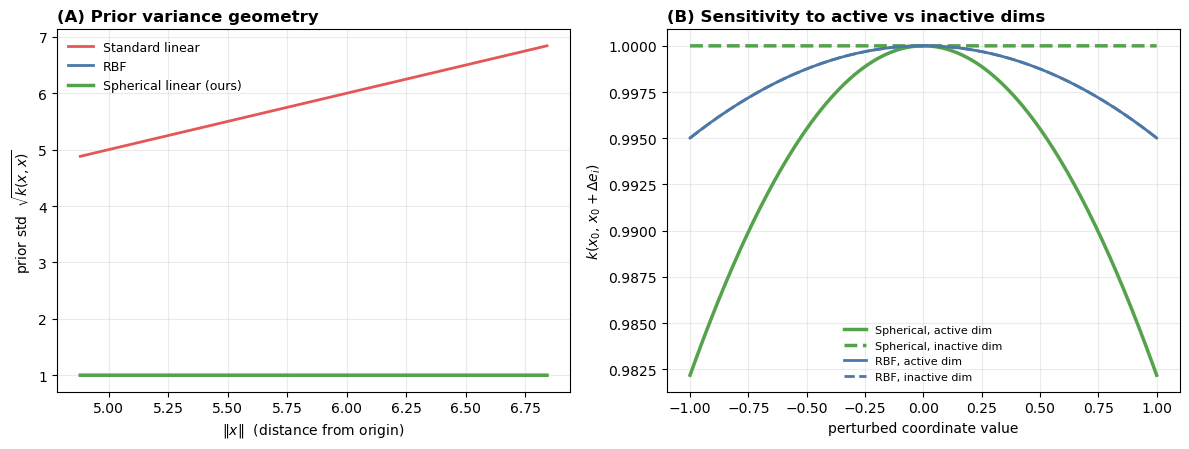

In [9]:
import matplotlib.pyplot as plt

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.6))

# (A) prior std vs ||x||
order = np.argsort(norms)
ns = norms[order]
axA.plot(ns, np.sqrt(linear_diag(pool))[order], color=COLORS["linear"], lw=2, label="Standard linear")
axA.plot(ns, np.sqrt(rbf_diag(pool))[order], color=COLORS["rbf"], lw=2, label="RBF")
axA.plot(ns, np.sqrt(spherical_linear_diag(pool))[order], color=COLORS["spherical_linear"], lw=2.5, label="Spherical linear (ours)")
axA.set_xlabel(r"$\|x\|$  (distance from origin)")
axA.set_ylabel(r"prior std  $\sqrt{k(x,x)}$")
axA.set_title("(A) Prior variance geometry", fontweight="bold", loc="left")
axA.legend(frameon=False, fontsize=9); axA.grid(alpha=0.25)

# (B) sensitivity to active vs inactive coordinate
coords = np.linspace(LOW, HIGH, 200)
x0 = np.zeros((1, D))
def perturb(dim):
    Xp = np.repeat(x0, coords.size, axis=0); Xp[:, dim] = coords; return Xp
Xa, Xi = perturb(ACTIVE[0]), perturb(D // 2)
axB.plot(coords, spherical_linear_kernel(x0, Xa)[0], color=COLORS["spherical_linear"], lw=2.5, label="Spherical, active dim")
axB.plot(coords, spherical_linear_kernel(x0, Xi)[0], color=COLORS["spherical_linear"], lw=2.5, ls="--", label="Spherical, inactive dim")
axB.plot(coords, rbf_kernel(x0, Xa)[0], color=COLORS["rbf"], lw=2, label="RBF, active dim")
axB.plot(coords, rbf_kernel(x0, Xi)[0], color=COLORS["rbf"], lw=2, ls="--", label="RBF, inactive dim")
axB.set_xlabel("perturbed coordinate value")
axB.set_ylabel(r"$k(x_0,\, x_0 + \Delta e_i)$")
axB.set_title("(B) Sensitivity to active vs inactive dims", fontweight="bold", loc="left")
axB.legend(frameon=False, fontsize=8); axB.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("kernel_geometry.png", dpi=150)
plt.show()

## Figure 2 — Bayesian optimization results

Left: best objective found so far vs iteration. Right: boundary-seeking of the selected
points — mean boundary fraction (bars, |coord| > 0.95) and mean $\|x\|$ (diamonds).

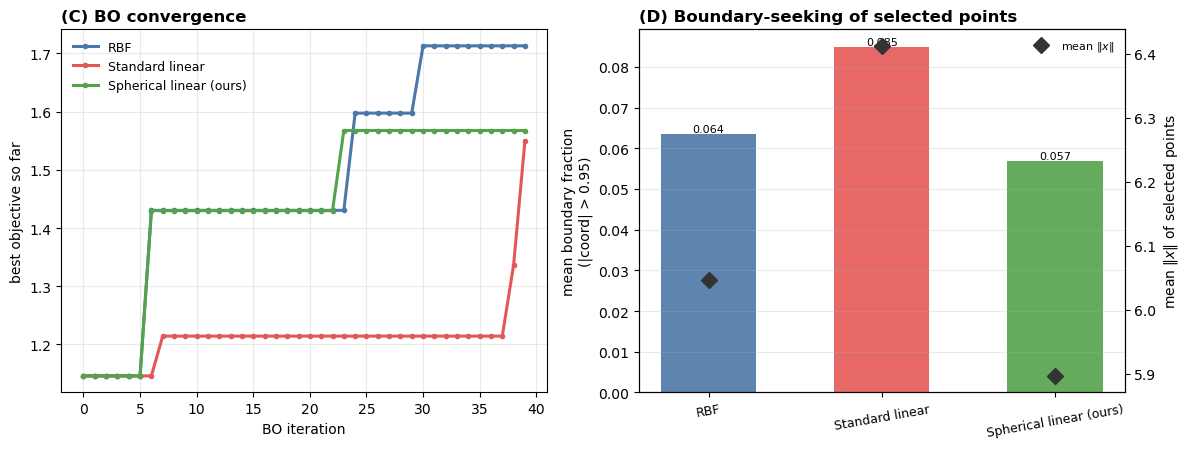

In [10]:
fig, (axC, axD) = plt.subplots(1, 2, figsize=(12, 4.6))

# (C) convergence
for name in MODELS:
    m = all_metrics[name]
    axC.plot([r["iter"] for r in m], [r["best_y"] for r in m],
             color=COLORS[name], lw=2.2, marker="o", ms=3, label=LABELS[name])
axC.set_xlabel("BO iteration"); axC.set_ylabel("best objective so far")
axC.set_title("(C) BO convergence", fontweight="bold", loc="left")
axC.legend(frameon=False, fontsize=9); axC.grid(alpha=0.25)

# (D) boundary-seeking
bfrac = [summary[n]["mean_boundary_fraction"] for n in MODELS]
xnorm = [summary[n]["mean_x_next_norm"] for n in MODELS]
xpos = np.arange(len(MODELS))
bars = axD.bar(xpos, bfrac, color=[COLORS[n] for n in MODELS], width=0.55, alpha=0.9)
axD.set_xticks(xpos); axD.set_xticklabels([LABELS[n] for n in MODELS], fontsize=9, rotation=10)
axD.set_ylabel("mean boundary fraction\n(|coord| > 0.95)")
axD.set_title("(D) Boundary-seeking of selected points", fontweight="bold", loc="left")
axD.grid(alpha=0.25, axis="y")
for b, v in zip(bars, bfrac):
    axD.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax2 = axD.twinx()
ax2.plot(xpos, xnorm, color="#333", marker="D", ms=8, ls="none", label=r"mean $\|x\|$")
ax2.set_ylabel(r"mean $\|x\|$ of selected points")
ax2.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
fig.savefig("bo_results.png", dpi=150)
plt.show()

## (Optional) check against the reference run

If `summary.json` / `kernel_diagnostics.json` from `runs/001` are placed next to this
notebook, confirm the reproduction matches. The checks are skipped if the files are absent —
the notebook is fully self-contained without them.

In [11]:
import json, os
if os.path.exists("summary.json"):
    ref = json.load(open("summary.json"))
    err = max(abs(summary[k][f] - ref[k][f]) for k in ref for f in ref[k])
    print(f"max abs diff vs reference summary.json: {err:.3e}")
else:
    print("summary.json not found next to the notebook — skipping (self-contained).")

max abs diff vs reference summary.json: 0.000e+00
